# L6. Teaching It to See

The device learns something new by writing example vectors to memory: no retraining, no fine-tuning. Pick a subject, give it a name, and teach it yourself. Then everything you built lands in one assistant that answers questions about your day and recognizes what you taught it, offline.

## 1. The subject you'll teach

Pick one object you have with you. Upload two or more photos of it on the left, taken from different angles or in different places, and one more on the right. That last photo is held back: the device meets it once before it has been taught anything, and once after. Skip the upload and a bundled rubber duck stands in.


In [1]:
from helper import photo_uploader

MY_LABEL = "rubber duck"      # the name it learns

# What it should remember about your subject, and how you'll ask for it.
MY_NOTE = "Rubber duck for the bath, from the toy shop on Elm Street"
MY_QUESTION = "what did I get at the toy shop?"

photo_uploader()

## 2. An object-memory shard

One shard for objects, image vectors only, plus the photos you just uploaded.


In [2]:
from helper import (embed_image, embed_text, fresh_start,
                    load_memories, no_network, object_photos,
                    recall, receipt_table, recognition_result,
                    recognize, score_gap_chart, show_images,
                    store_notes, store_photo_memories, text_search)
from qdrant_edge import (Distance, EdgeConfig, EdgeShard,
                         EdgeVectorParams, Point, UpdateOperation)

OBJECT_DIR = fresh_start("./object_shard")

config = EdgeConfig(
    vectors={
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
object_shard = EdgeShard.create(OBJECT_DIR, config)
RECOGNIZE_THRESHOLD = 0.80

teach_photos, test_photo = object_photos()
print(f'Teaching "{MY_LABEL}". Threshold =', RECOGNIZE_THRESHOLD)

Using the bundled example: a rubber duck, 2 photos to teach with and 1 to test with
Teaching "rubber duck". Threshold = 0.8


## 3. Give it a few memories first

Teaching is writing: embed a few example photos and store them under a label. No retraining, just new memories. Three everyday things go in first.


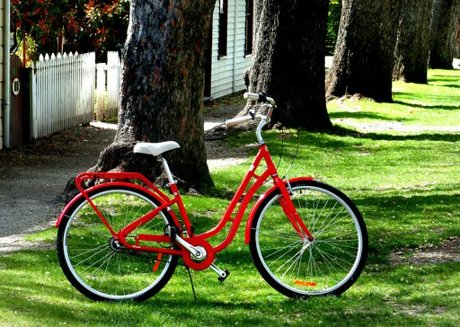
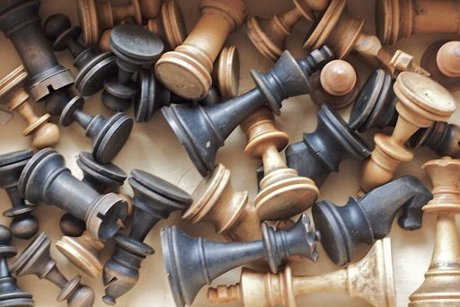
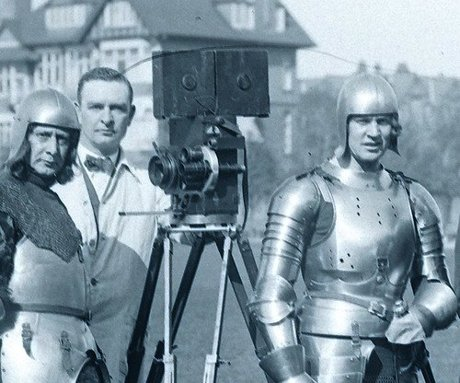

In [3]:
def teach(shard, label, view_paths, start_id):
    vectors = embed_image(view_paths)
    shard.update(UpdateOperation.upsert_points([
        Point(id=start_id + i, vector={"image": v},
              payload={"label": label, "file": p})
        for i, (p, v) in enumerate(zip(view_paths, vectors))
    ]))
    shard.optimize()
    # flush to disk now: a taught memory should survive a power cut
    shard.flush()


seeds = {"a bicycle": "bicycle.jpg",
         "chess pieces": "chess_set.jpg",
         "a camera": "camera.jpg"}
for i, (label, file) in enumerate(seeds.items()):
    photo = f"./ro_shared_data/bank/{file}"
    teach(object_shard, label, [photo], start_id=i)

show_images([f"./ro_shared_data/bank/{f}" for f in seeds.values()],
            captions=list(seeds))

## 4. Show it your subject: not recognized yet

`recognize` searches the image vector for the closest stored photo, the way Lesson 3 did, and compares the score to the threshold. Below the bar, the answer is that it does not know this object.


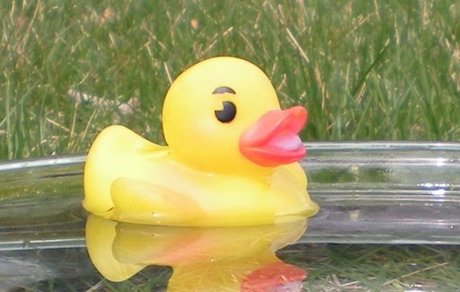
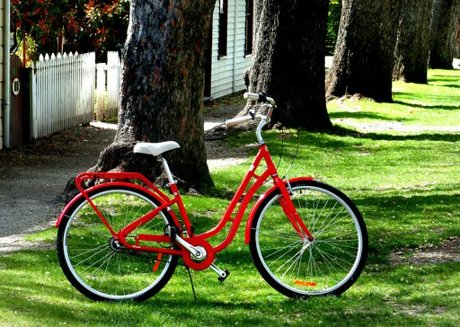

In [4]:
top, known = recognize(object_shard, test_photo,
                       RECOGNIZE_THRESHOLD)
recognition_result(test_photo, top, known)

## 5. Teach it, recognize it

In [5]:
teach(object_shard, MY_LABEL, teach_photos, start_id=100)
print(f'Taught "{MY_LABEL}" from {len(teach_photos)} photos.',
      object_shard.info().points_count, "photos in memory")

Taught "rubber duck" from 2 photos. 5 photos in memory



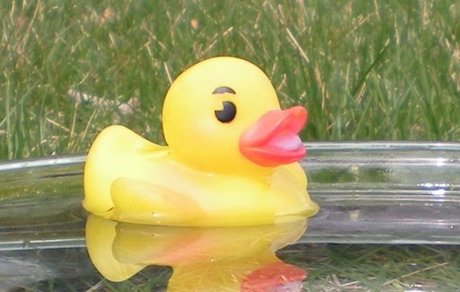
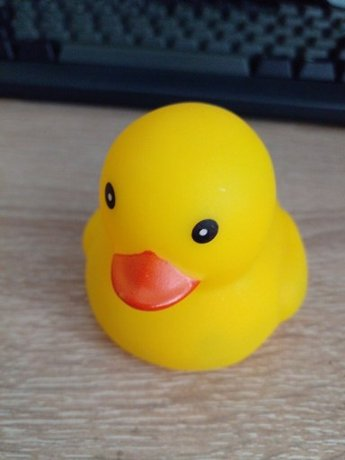

In [6]:
top, known = recognize(object_shard, test_photo,
                       RECOGNIZE_THRESHOLD)
recognition_result(test_photo, top, known)

## 6. Inspect the threshold gap

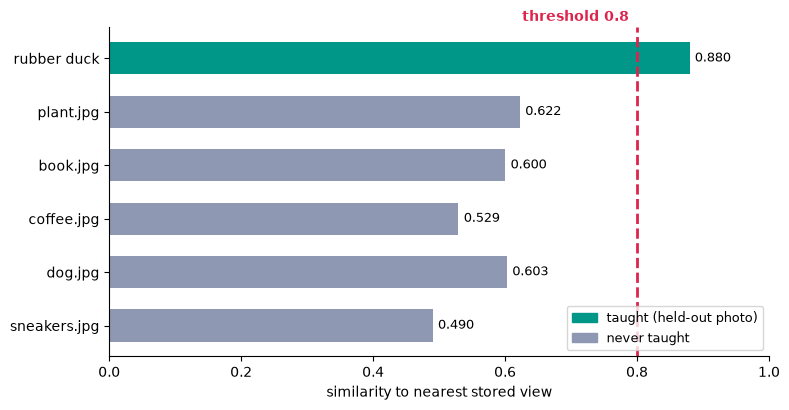

In [7]:
top, _ = recognize(object_shard, test_photo, RECOGNIZE_THRESHOLD)
taught = [(MY_LABEL, top.score)]

foreign = []
for name in ["plant.jpg", "book.jpg", "coffee.jpg",
             "dog.jpg", "sneakers.jpg"]:
    t, _ = recognize(object_shard, f"./ro_shared_data/images/{name}",
                     RECOGNIZE_THRESHOLD)
    foreign.append((name, t.score))

score_gap_chart(taught, foreign, RECOGNIZE_THRESHOLD)

## 7. Assemble the assistant

Everything the course built lands in one shard: today's day, the earlier history, and your subject.

In [8]:
ASSISTANT_DIR = fresh_start("./assistant_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
assistant_shard = EdgeShard.create(ASSISTANT_DIR, config)

day = load_memories("./ro_shared_data/memories.json")
history = load_memories("./ro_shared_data/recent_days.json")

notes = [m for m in day + history
         if m["source_type"] in ("text", "voice")]
store_notes(assistant_shard, notes)

photos = [m for m in day if m["source_type"] == "photo"]
store_photo_memories(assistant_shard, photos,
                     "./ro_shared_data/images")

Stored 127 notes


Stored 17 photos. Total: 144 memories


In [9]:
# One memory, two ways in: the photo's vector and the note's, one point.
my_memory = Point(
    id=5000,
    vector={"image": embed_image([teach_photos[0]])[0],
            "text": embed_text([MY_NOTE])[0]},
    payload={"label": MY_LABEL, "file": teach_photos[0],
             "note": MY_NOTE},
)
assistant_shard.update(UpdateOperation.upsert_points([my_memory]))
assistant_shard.optimize()
assistant_shard.flush()

receipt_table([
    ("today", f"{len(day)} captures: photos, voice, text"),
    ("history", f"{len(history)} earlier notes"),
    ("taught", f"{MY_LABEL}: photo + note, one memory"),
    ("total", f"{assistant_shard.info().points_count} memories,"
              " one shard"),
], title="Your assistant's memory")

,
today,"42 captures: photos, voice, text"
history,102 earlier notes
taught,"rubber duck: photo + note, one memory"
total,"145 memories, one shard"


## 8. Two ways into one memory

Show it the held-out photo, then ask for the same memory in words. The photo matches the image vector, the question matches the text vector, and both land on the same point.



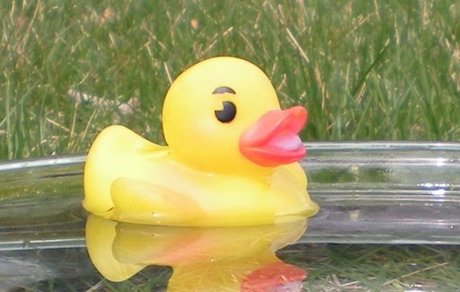
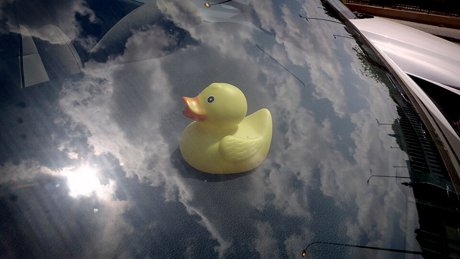

I remember this: Rubber duck for the bath, from the toy shop on Elm Street
Asked by words  -> memory 5000: Rubber duck for the bath, from the toy shop on Elm Street
Shown the photo -> memory 5000: rubber duck · score 0.856


In [10]:
top, known = recognize(assistant_shard, test_photo,
                       RECOGNIZE_THRESHOLD)
display(recognition_result(test_photo, top, known))
if known:
    print("I remember this:", top.payload["note"])

found = text_search(assistant_shard, MY_QUESTION, limit=1)[0]
print(f"Asked by words  -> memory {found.id}:",
      found.payload["note"])
print(f"Shown the photo -> memory {top.id}:", top.payload["label"],
      f"· score {top.score:.3f}")

## 9. It persists, with no server in the loop

Close the shard, block the network, reopen it from disk. Both skills come back.

In [11]:
before = assistant_shard.info().points_count
assistant_shard.close()
with no_network():
    assistant_shard = EdgeShard.load(ASSISTANT_DIR)
    hits = recall(assistant_shard, "the ramen place downtown")
    top, known = recognize(assistant_shard, test_photo,
                           RECOGNIZE_THRESHOLD)

recalled = hits["Voice Notes"][0].payload["transcript"][:38]
recognized = top.payload["label"] if known else "UNKNOWN"

receipt_table([
    ("path", ASSISTANT_DIR),
    ("memories", before),
    ("recalled offline", recalled),
    ("recognized offline", recognized),
    ("network access", "blocked"),
], title="Your assistant persists, offline")

,
path,./assistant_shard
memories,145
recalled offline,"Note to self, the ramen downtown was i"
recognized offline,rubber duck
network access,blocked
